<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/APRENDIZADO_AULA_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# importar base de dados
from google.colab import files
uploaded = files.upload()

Saving 01-04T184148_000_mode1.csv to 01-04T184148_000_mode1.csv


In [ ]:
# Ler o arquivo csv
df = pd.read_csv("01-04T184148_000_mode1.csv")

In [ ]:
# Selecionar colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


In [ ]:
# Selecionar as colunas para os dados de treinamento
X = df[numeric_cols]
y = df["pSpintor::VAX_speed"]

In [ ]:
# Verificar e remover colunas faltantes
cols_to_remove = []

for col in X.columns:
    if X[col].isnull().any():
        print(f"Coluna {col} contém valores faltantes.")
        cols_to_remove.append(col)

X = X.drop(columns=cols_to_remove)


In [ ]:
# Remover target do X
X = X.drop(columns=["pSpintor::VAX_speed"])

In [ ]:
# Dividir os dados entre conjunto de treinamento e conjunto de validação
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [ ]:
# Treinar a regressão linear
model_val_cruz = LinearRegression()
model_val_cruz.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Fazer predições no conjunto de validação
y_pred_val_cruz = model_val_cruz.predict(X_val)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Calcular as métricas de erro de validação
mse_val_cruz = mean_squared_error(y_val, y_pred_val_cruz)
r2_val_cruz = r2_score(y_val, y_pred_val_cruz)
print(f"R2 Score: {r2_val_cruz}")
print(f"MSE: {mse_val_cruz}")

R2 Score: 0.6545703839178361
MSE: 1801.3044499055513


In [ ]:
# Utilizar o método de k-fold cross validation
n = len(X)
k = 5  # Changed k to 5 for valid R2 calculation
fold_size = n // k
cv_scores = []

In [ ]:
for fold in range(k):
  print(f"Fold: {fold}")
  start = fold * fold_size
  end = start + fold_size if fold < k-1 else n

  test_indices_fold = list(range(start, end))
  train_indices_fold = list(range(0, start)) + list(range(end, n))

  #separar dados
  X_train_fold = X.iloc[train_indices_fold]
  y_train_fold = y.iloc[train_indices_fold]

  X_test_fold = X.iloc[test_indices_fold]
  y_test_fold = y.iloc[test_indices_fold]

  # Treinar o modelo e prever o target
  model_fold = LinearRegression()
  model_fold.fit(X_train_fold, y_train_fold)
  y_pred_fold = model_fold.predict(X_test_fold)

  # Calcular as métricas de erro
  mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
  r2_fold = r2_score(y_test_fold, y_pred_fold)

  print(f"R2 Score: {r2_fold}")
  print(f"MSE: {mse_fold}")

  cv_scores.append((r2_fold, mse_fold))

Fold: 0
R2 Score: 0.0
MSE: 7520.194010181822
Fold: 1
R2 Score: 0.0
MSE: 957.3582556351853
Fold: 2
R2 Score: 0.0
MSE: 2897.587132763162
Fold: 3
R2 Score: -2.1524238229677817
MSE: 6935.115396858791
Fold: 4
R2 Score: -5.146608122569311e+29
MSE: 26607.340371232942


In [ ]:
# Bootstrap

n_bootstrap = 500
n_samples = len(X)
r2_score_boot = []
coefficients_boot = []

In [ ]:
# Executar bootstrap

for i in range(n_bootstrap):
  print(f"Executando iteração {i+1}")

  #Amostragem
  bootstrap_indices = np.random.choice(range(n_samples), n_samples, replace = True)

  x_boot = X.iloc[bootstrap_indices]
  y_boot = y.iloc[bootstrap_indices]

  # Treinar o modelo
  model_boot = LinearRegression()
  model_boot.fit(x_boot, y_boot)

  #Fazer predições
  y_pred_boot = model_boot.predict(X_val)

  #Calcular as métricas de erro
  mse_boot = mean_squared_error(y_val, y_pred_boot)
  r2_boot = r2_score(y_val, y_pred_boot)

  #Mostrar métricas de erro
  print(f"R2 Score: {r2_boot}")
  print(f"MSE: {mse_boot}")

  r2_score_boot.append(r2_boot)
  coefficients_boot.append(model_boot.coef_)

Executando iteração 1
R2 Score: 0.6489430506409215
MSE: 1830.6491846963195
Executando iteração 2
R2 Score: 0.6550203415793945
MSE: 1798.9580652868065
Executando iteração 3
R2 Score: 0.6543784305862044
MSE: 1802.3054248490553
Executando iteração 4
R2 Score: 0.6503914883846964
MSE: 1823.0960472934962
Executando iteração 5
R2 Score: 0.656303977913054
MSE: 1792.2643142815907
Executando iteração 6
R2 Score: 0.6524834545522576
MSE: 1812.1871159475993
Executando iteração 7
R2 Score: 0.6573201309804223
MSE: 1786.965402558861
Executando iteração 8
R2 Score: 0.6580572228384464
MSE: 1783.1217053712633
Executando iteração 9
R2 Score: 0.6547030546382615
MSE: 1800.612614730024
Executando iteração 10
R2 Score: 0.6567195644736652
MSE: 1790.0971639097131
Executando iteração 11
R2 Score: 0.6553321678943423
MSE: 1797.3319912544637
Executando iteração 12
R2 Score: 0.6534569847663547
MSE: 1807.1104687085467
Executando iteração 13
R2 Score: 0.6565609677714878
MSE: 1790.9241947492012
Executando iteração 14
R

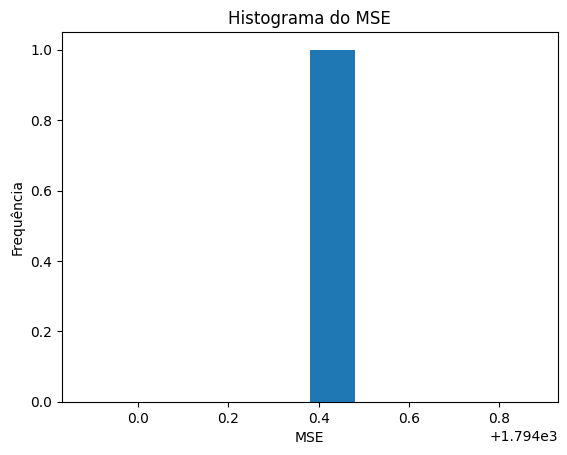

In [ ]:
# Histograma do MSE
plt.hist(mse_boot)
plt.xlabel("MSE")
plt.ylabel("Frequência")
plt.title("Histograma do MSE")
plt.show()

In [ ]:
# Best subset selection
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector

In [ ]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(X_train, y_train)

RFE(estimator=LinearRegression(), n_features_to_select=5)

In [ ]:
feature_names = X_train.columns


In [ ]:
selected_features = feature_names[rfe.support_]
print("Features selecionadas:", selected_features)

Features selecionadas: Index(['timestamp', 'pCut::Motor_Torque',
       'pCut::CTRL_Position_controller::Lag_error',
       'pSvolFilm::CTRL_Position_controller::Actual_position',
       'pSvolFilm::CTRL_Position_controller::Lag_error'],
      dtype='object')


In [ ]:
# Fazer predições
y_pred_rfe = rfe.predict(X_val)


In [ ]:
# Calcular e mostrar métricas de erro
mse_rfe = mean_squared_error(y_val, y_pred_rfe)
r2_rfe = r2_score(y_val, y_pred_rfe)

print(f"R2 Score: {r2_rfe}")
print(f"MSE: {mse_rfe}")

R2 Score: 0.5800472330771909
MSE: 2189.918734785823


In [ ]:
# Forward Subset Selection
forward_selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, direction='forward')
forward_selector.fit(X_train, y_train)

SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=5)

In [ ]:
forward_features = np.array(feature_names)[forward_selector.get_support()]

In [ ]:
print(f"Features selecionadas (Forward Subset Selection): {forward_features}")

Features selecionadas (Forward Subset Selection): ['timestamp' 'pCut::CTRL_Position_controller::Actual_position'
 'pSvolFilm::CTRL_Position_controller::Actual_position'
 'pSvolFilm::CTRL_Position_controller::Actual_speed'
 'pSvolFilm::CTRL_Position_controller::Lag_error']


In [ ]:

# Backward Subset Selection
backward_selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, direction='backward')
backward_selector.fit(X_train, y_train)


SequentialFeatureSelector(direction='backward', estimator=LinearRegression(),
                          n_features_to_select=5)

In [ ]:
np.array(feature_names)[backward_selector.get_support()]

array(['timestamp', 'pCut::CTRL_Position_controller::Actual_position',
       'pCut::CTRL_Position_controller::Actual_speed',
       'pSvolFilm::CTRL_Position_controller::Actual_position',
       'pSvolFilm::CTRL_Position_controller::Actual_speed'], dtype=object)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer, SplineTransformer
from sklearn.pipeline import make_pipeline, Pipeline

In [ ]:
# Regressão polinomial
X_train_poly = PolynomialFeatures(degree=2).fit_transform(X_train)
X_val_poly = PolynomialFeatures(degree=2).fit_transform(X_val)

In [ ]:
# Efetuar a regressão polinomial
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
# Fazer predições
y_pred_poly_val = model_poly.predict(X_val_poly)
y_pred_poly_train = model_poly.predict(X_train_poly)

In [ ]:
# Calcular as métricas de erro de treino de teste
mse_poly_train = mean_squared_error(y_train, y_pred_poly_train)
r2_poly_train = r2_score(y_train, y_pred_poly_train)
print(f"R2 Score: {r2_poly_train}")
print(f"MSE: {mse_poly_train}")

R2 Score: 0.9612572276419569
MSE: 215.64157402398507


In [ ]:
mse_poly_val = mean_squared_error(y_val, y_pred_poly_val)
r2_poly_val = r2_score(y_val, y_pred_poly_val)
print(f"R2 Score: {r2_poly_val}")
print(f"MSE: {mse_poly_val}")

R2 Score: 0.9571091901226663
MSE: 223.6617912741952


In [ ]:
# Dados do model
print(f"Coefficients: {model_poly.coef_}")
print(f"Intercept: {model_poly.intercept_}")
print(f"Número de parâmetros: {len(model_poly.coef_)}")

Coefficients: [ 1.87420675e-05  2.83125005e-07  2.32818746e-08  9.21265952e-10
  2.96517001e-06 -4.23721680e-06  7.40645735e-06  1.11829424e-07
  1.62660518e-10  3.19325559e-05  1.44512667e-05  7.63199149e-07
 -2.28669475e-04 -1.16714257e-01  2.68778629e-02 -1.48383647e-01
 -2.01330005e-05 -4.30592948e-05 -3.29468404e-05  1.51885785e-05
 -1.23304888e-03 -1.77480232e-03 -3.12694234e-02 -3.42019135e-05
  3.23878464e-05  3.66243405e-05 -5.26314790e-03 -4.26900310e-03
 -9.01969474e-02 -2.75541167e-06 -5.07309927e-10 -2.93713706e-07
  1.35919167e-07 -3.77462256e-07 -1.56030926e-05 -4.69102109e-06
  3.48059986e-05  1.93460598e-05  9.49562526e-03 -8.02757234e-06
  4.47254976e-05  1.84016768e-03  3.42515979e-05  1.36986684e-02
 -1.99934381e-05]
Intercept: -26856327.05937738
Número de parâmetros: 45


In [ ]:
len(X_train.columns)

8

In [ ]:
# Criar as regiões para a função degrau
step_function = Pipeline([("binning", KBinsDiscretizer(n_bins=10, encode="onehot-dense")), ("regressor", LinearRegression())])

In [ ]:
# Ajustar o modelo da função degrau
step_function.fit(X_train, y_train)

Pipeline(steps=[('binning', KBinsDiscretizer(encode='onehot-dense', n_bins=10)),
                ('regressor', LinearRegression())])

In [ ]:

# Fazer as predições nos dados de treino e teste
y_train_step = step_function.predict(X_train)
y_val_step = step_function.predict(X_val)

In [ ]:
# Calcular as métricas de erro e mostrar na tela
mse_train_step = mean_squared_error(y_train, y_train_step)
mse_val_step = mean_squared_error(y_val, y_val_step)
r2_train_step = r2_score(y_train, y_train_step)
r2_val_step = r2_score(y_val, y_val_step)

print(f"R2 Score Train: {r2_train_step}")
print(f"MSE Train: {mse_train_step}")

print(f"R2 Score Val: {r2_val_step}")
print(f"MSE Val: {mse_val_step}")


R2 Score Train: 0.9563404606608393
MSE Train: 243.00821059606338
R2 Score Val: 0.9541934313620175
MSE Val: 238.8665362812308


In [ ]:
# Ajustar um modelo de splines
spline_model = make_pipeline(SplineTransformer(n_knots=2, degree=2, knots="uniform"), LinearRegression())

In [ ]:
# Ajustar o modelo continuação
spline_model.fit(X_train, y_train)

Pipeline(steps=[('splinetransformer', SplineTransformer(degree=2, n_knots=2)),
                ('linearregression', LinearRegression())])

In [ ]:
# Fazer as predições para os dados de treinamento e validação
y_train_spline = spline_model.predict(X_train)
y_val_spline = spline_model.predict(X_val)

In [ ]:
# Calcular as métricas R2 e MSE e mostrar na tela
mse_train_spline = mean_squared_error(y_train, y_train_spline)
mse_val_spline = mean_squared_error(y_val, y_val_spline)

r2_train_spline = r2_score(y_train, y_train_spline)
r2_val_spline = r2_score(y_val, y_val_spline)

print(f"R2 Score Train: {r2_train_spline}")
print(f"MSE Train: {mse_train_spline}")
print(f"MSE Val: {mse_val_spline}")
print(f"R2 Score Val: {r2_val_spline}")

R2 Score Train: 0.8999927023835113
MSE Train: 556.6388195610793
MSE Val: 504.2630575212172
R2 Score Val: 0.9032993038055808
